# Linear Regression Salary Data Homework

In [ ]:
%matplotlib inline
import warnings
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
BASE_DIR = Path.cwd()

In [ ]:
try:
    import kagglehub
    path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")
    filepath = os.path.join(path, "Salary_dataset.csv")
    if not os.path.exists(filepath):
        print("Dataset not found. Please check the Kaggle dataset path.")
        raise FileNotFoundError(f"Dataset not found at {filepath}")
except (ImportError, FileNotFoundError):
    filepath = BASE_DIR / "dataset" / "Salary_dataset.csv"


df = pd.read_csv(filepath)
X = df[['YearsExperience']].values
y = df[['Salary']].values
df.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_test, dtype=torch.float32)
y_val_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

In [ ]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [ ]:
model = torch.nn.Linear(in_features=X_train.shape[1],out_features=1)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [ ]:
num_epochs = 1000
loss_history = []

for epoch in range(num_epochs):
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if (epoch + 1) % 100 == 0:
        message = f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.6f}"
        print(message)

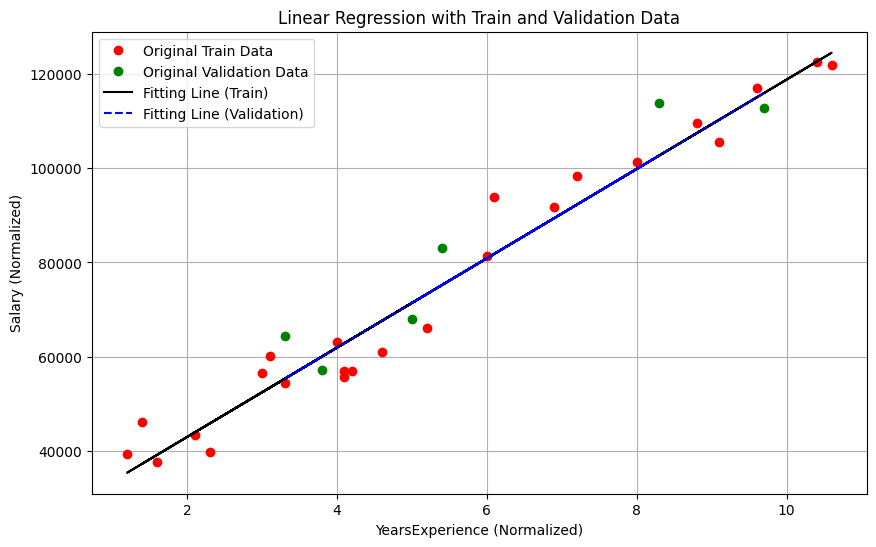

In [41]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot original training data
plt.plot(X_train_tensor.numpy(), y_train_tensor.numpy(), 'ro', label='Original Train Data')

# Plot original validation data
plt.plot(X_val_tensor.numpy(), y_val_tensor.numpy(), 'go', label='Original Validation Data')

# Plot fitting line for training data
plt.plot(X_train_tensor.numpy(), y_pred_train.data.numpy(), 'k-', label='Fitting Line (Train)')

# Plot fitting line for validation data
plt.plot(X_val_tensor.numpy(), y_pred_val.data.numpy(), 'b--', label='Fitting Line (Validation)')

plt.xlabel('YearsExperience (Normalized)')
plt.ylabel('Salary (Normalized)')
plt.title('Linear Regression with Train and Validation Data')
plt.legend()
plt.grid(True)
plt.show()

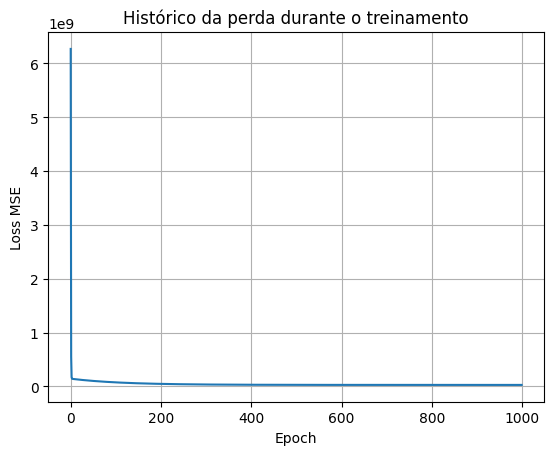

In [40]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss MSE")
plt.title("Histórico da perda durante o treinamento")

plt.grid(True)
plt.show()